# Where did the coffee go?

A shop buys beans. A shop sells coffee. At the end of the week those two numbers should agree, and
they never do.

This notebook takes the bean-counter event log — every delivery, every sale, every bag binned — folds
it forward into the stock we *should* have, and sets that against what someone actually found on the
shelf on Monday morning. The gap is **shrinkage**, and the point of the exercise is not to discover
that it exists. It always exists. The point is to find out how big it is, which items it lives in,
and whether its shape looks like theft, waste, or a barista pulling heavy shots.

The event log is what makes this possible at all. A system that stored a single mutable `quantity`
column could tell you that you are short 580 g of Yirgacheffe. It could not tell you what happened
in between, because it threw that away as it went.

## The read path

**This notebook reads an exported snapshot from `analytics/data/`. It does not connect to the
application database.**

That is deliberate, and it is worth one paragraph because the alternative is so convenient. A
notebook with live database credentials is a notebook that gets emailed, committed, copied to a
laptop, and eventually run against production by someone who thought they were on staging — and it
holds a connection that no application code path audits. Keeping analysis on a batch-exported
snapshot means the credential lives in one script (`scripts/export.py`) that runs as a job, and the
notebook itself holds nothing worth stealing.

The direct-to-database path exists for the rare case where you genuinely need it, and it is opt-in
behind an environment variable so nobody takes it by accident. Regenerate the sample snapshot at any
time with `make fixtures`; refresh from a live database with `make analytics-export` from the repo
root.

In [1]:
import os
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

# The category vocabulary lives with the snapshot schema, next to the fixture generator and
# the exporter that write these files -- one definition, so the notebook cannot select on a
# word the data does not use. It did once: the fixtures said "dairy", the shop says "milk",
# and the milk section rendered empty against real data without anything failing.
sys.path.append(str(Path.cwd().parent / "scripts"))
from schema import BEANS, CATEGORIES, MILK, PACKAGING, check_vocabulary, select_category

load_dotenv()

DATA_DIR = Path.cwd().parent / "data"
ALLOW_DB = os.environ.get("BEANCOUNTER_ANALYTICS_ALLOW_DB") == "1"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print("data dir:", DATA_DIR)
print("known categories:", ", ".join(CATEGORIES))
print("direct-to-database read:", "ENABLED (opt-in)" if ALLOW_DB else "disabled (default)")

data dir: /Users/andrewwint/Documents/PROJECTS/PRODUCTS/discipline/projects/bean-counter/analytics/data
known categories: beans, milk, packaging
direct-to-database read: disabled (default)


In [2]:
def load_snapshot() -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """Load the event log and the read model.

    Default path: the exported Parquet snapshot. The opt-in path reads the application
    database directly and is gated on BEANCOUNTER_ANALYTICS_ALLOW_DB=1 -- see "The read
    path" above for why that gate is here.
    """
    if ALLOW_DB:
        print(
            "WARNING: reading the live application database from a notebook.\n"
            "         This is the opt-in path. Do not save output cells containing customer or\n"
            "         supplier data, and do not commit this notebook with the flag still set."
        )
        import psycopg
        from export import EVENTS_SQL, STOCK_SQL

        with psycopg.connect(os.environ["DATABASE_URL"]) as conn:
            return pd.read_sql(EVENTS_SQL, conn), pd.read_sql(STOCK_SQL, conn), "live database"

    events_file, stock_file = DATA_DIR / "events.parquet", DATA_DIR / "stock.parquet"
    if not (events_file.exists() and stock_file.exists()):
        raise FileNotFoundError(
            f"No snapshot in {DATA_DIR}.\n"
            "  Sample data (no database needed):  make fixtures\n"
            "  Live data:                         make analytics-export   (from the repo root)"
        )

    return pd.read_parquet(events_file), pd.read_parquet(stock_file), "exported snapshot"


events, stock, source = load_snapshot()

# Fails loudly if the shop starts using a category this layer has never heard of, rather
# than letting that item quietly fall out of every section below.
check_vocabulary(stock)

print(f"source: {source}")
print(f"{len(events)} events across {events.item_id.nunique()} items, "
      f"{events.occurred_at.min():%Y-%m-%d} to {events.occurred_at.max():%Y-%m-%d}")
stock

source: exported snapshot
86 events across 8 items, 2026-08-03 to 2026-08-10


,item_id,name,category,base_unit,quantity,last_event_at
0,bean-yirgacheffe,Yirgacheffe,beans,g,4980,2026-08-10 07:00:00+00:00
1,bean-huila,Huila,beans,g,2610,2026-08-10 07:00:00+00:00
2,bean-sumatra,Sumatra Mandheling,beans,g,1400,2026-08-10 07:00:00+00:00
3,milk-whole,Whole Milk,milk,ml,14200,2026-08-10 07:00:00+00:00
4,milk-oat,Oat Milk,milk,ml,4250,2026-08-10 07:00:00+00:00
5,cup-12oz,12oz Cup,packaging,each,262,2026-08-10 07:00:00+00:00
6,lid-12oz,12oz Lid,packaging,each,320,2026-08-10 07:00:00+00:00
7,cup-16oz,16oz Cup,packaging,each,386,2026-08-09 18:00:00+00:00


## Everything is an integer in a base unit

Beans are grams. Milk is milliliters. Cups are cups. Nothing in the log, the API, or this notebook
stores `1.5 kg` — it stores `1500`, and the conversion to kilograms happens at exactly one place: the
moment a number is printed for a human.

That rule is why the arithmetic below is trustworthy. Floating-point drift in an inventory system
does not announce itself; it shows up three weeks later as an unexplainable shortfall, which is
indistinguishable from the thing this notebook is trying to measure. The helper below is the display
edge, and it is the only place a float is allowed to appear.

In [3]:
def human(quantity: int, base_unit: str) -> str:
    """Format a base-unit integer for a human. The ONLY place this notebook divides."""
    if base_unit == "g":
        return f"{quantity / 1000:,.2f} kg"
    if base_unit == "ml":
        return f"{quantity / 1000:,.2f} L"
    return f"{quantity:,} each"


for row in stock.itertuples():
    print(f"{row.name:<22} {human(row.quantity, row.base_unit):>12}   (stored as {row.quantity} {row.base_unit})")

Yirgacheffe                 4.98 kg   (stored as 4980 g)
Huila                       2.61 kg   (stored as 2610 g)
Sumatra Mandheling          1.40 kg   (stored as 1400 g)
Whole Milk                  14.20 L   (stored as 14200 ml)
Oat Milk                     4.25 L   (stored as 4250 ml)
12oz Cup                   262 each   (stored as 262 each)
12oz Lid                   320 each   (stored as 320 each)
16oz Cup                   386 each   (stored as 386 each)


## What the log actually holds

Four event types, and only four. Notice that there is no "stock level" event — the shop never
records how much it has, only what happened to what it has. Everything else is derived.

In [4]:
summary = (
    events.assign(reason=events.reason.fillna("-"))
    .groupby(["event_type", "reason"], dropna=False)
    .agg(events=("sequence", "size"), total_quantity=("quantity", "sum"))
    .reset_index()
)
summary

,event_type,reason,events,total_quantity
0,ItemDefined,-,8,0
1,StockCounted,-,14,0
2,StockDepleted,sale,54,132914
3,StockDepleted,sample,1,100
4,StockDepleted,waste,1,400
5,StockReceived,-,8,112600


## Step 1 — fold the log, and check it against the read model

The contract says current stock is the last physical count plus every movement recorded after it:

```
qty(item) = last StockCounted.countedQuantity
          + receipts   after that count
          - depletions after that count
```

The application maintains `item_stock` for exactly this. We recompute it here from the raw log, in
SQL, and assert the two agree — because if this notebook's fold disagrees with the application's,
every number further down is worthless. This is the cheap check that makes the expensive analysis
believable.

Two things have to be true for it to mean anything: the numbers must match, **and every item in the
read model must have been looked at**. An assertion over rows that survived a join is only as good
as the join — an item that has never been counted has no baseline row to join to, and the check
would pass by quietly not examining it. So the fold starts from every defined item, folds the
never-counted case from 0 the way the contract says the application does, and asserts coverage
alongside agreement.

In [5]:
con = duckdb.connect()
con.register("events", events)
con.register("stock", stock)

REFOLD_SQL = """
WITH defined AS (
    -- Every item the read model can hold: per the contract, only streams with an
    -- ItemDefined appear in item_stock. Starting from these rather than from the items
    -- that happen to have been counted is what makes this check cover all of them.
    SELECT DISTINCT item_id
    FROM events
    WHERE event_type = 'ItemDefined'
),
last_count AS (
    SELECT item_id, MAX(sequence) AS count_seq
    FROM events
    WHERE event_type = 'StockCounted'
    GROUP BY item_id
),
baseline AS (
    -- An item with no count folds from 0 over its whole stream: sequence > 0 is every row.
    -- This is coalesce(counted_at_sequence, 0) from 002_item_stock.sql, spelled out.
    SELECT
        d.item_id,
        COALESCE(l.count_seq, 0)        AS count_seq,
        COALESCE(e.counted_quantity, 0) AS counted
    FROM defined d
    LEFT JOIN last_count l ON l.item_id = d.item_id
    LEFT JOIN events e     ON e.item_id = l.item_id AND e.sequence = l.count_seq
),
after_count AS (
    SELECT
        b.item_id,
        COALESCE(SUM(e.quantity) FILTER (WHERE e.event_type = 'StockReceived'), 0) AS received_after,
        COALESCE(SUM(e.quantity) FILTER (WHERE e.event_type = 'StockDepleted'), 0) AS depleted_after
    FROM baseline b
    LEFT JOIN events e ON e.item_id = b.item_id AND e.sequence > b.count_seq
    GROUP BY b.item_id
)
SELECT
    b.item_id,
    b.counted + a.received_after - a.depleted_after AS folded_quantity
FROM baseline b
JOIN after_count a USING (item_id)
"""

check = (
    con.sql(REFOLD_SQL).df()
    # Outer, so neither side can hide a row by being absent from the other: an item the
    # fold misses shows up here with a null folded_quantity and fails, instead of
    # disappearing. Quantities stay integers (nullable) -- no floats in a stock table.
    .merge(stock[["item_id", "name", "quantity"]], on="item_id", how="outer", indicator=True)
    .astype({"folded_quantity": "Int64", "quantity": "Int64"})
    .assign(agrees=lambda d: (d["_merge"] == "both") & (d.folded_quantity == d.quantity))
)

# Coverage is part of the assertion, not a nicety. `check.agrees.all()` on its own passes
# just as happily over a row that was never examined as over one that agreed -- which is
# what happened here: an inner join dropped every never-counted item and the check went
# green without ever looking at it.
unchecked = sorted(set(stock.item_id) - set(check.item_id))
assert not unchecked, f"stock rows the fold never checked: {unchecked}"
assert len(check) == len(stock), f"checked {len(check)} rows against {len(stock)} stock rows"
assert check.agrees.all(), check[~check.agrees]

never_counted = sorted(set(stock.item_id) - set(events.item_id[events.event_type == "StockCounted"]))
print(f"fold matches the application read model for all {len(check)} items "
      f"-- that is every row in the read model, not just the counted ones")
print(f"never counted (folded from 0 over all events, and checked): {never_counted or 'none'}")
check[["item_id", "name", "quantity", "folded_quantity", "agrees"]]


fold matches the application read model for all 8 items -- that is every row in the read model, not just the counted ones
never counted (folded from 0 over all events, and checked): ['cup-16oz']


,item_id,name,quantity,folded_quantity,agrees
0,bean-huila,Huila,2610,2610,True
1,bean-sumatra,Sumatra Mandheling,1400,1400,True
2,bean-yirgacheffe,Yirgacheffe,4980,4980,True
3,cup-12oz,12oz Cup,262,262,True
4,cup-16oz,16oz Cup,386,386,True
5,lid-12oz,12oz Lid,320,320,True
6,milk-oat,Oat Milk,4250,4250,True
7,milk-whole,Whole Milk,14200,14200,True


## Step 2 — the question the read model cannot answer

Here is the uncomfortable thing about the fold above: **it always agrees with the last count.** A
`StockCounted` event is an absolute reset. The moment someone counts the shelf, the system adopts
that number and the disagreement that prompted the count vanishes from the read model.

So the shrinkage is not in `item_stock`. It is in the gap *between* two counts, and you can only see
it by replaying the window between them:

```
expected_at_count = previous count
                  + everything received  in between
                  - everything depleted  in between   (sales, waste, samples)

variance          = what was actually counted - expected_at_count
```

A negative variance means the shelf held less than the log says it should have. That is coffee that
left the building without being recorded.

In [6]:
VARIANCE_SQL = """
WITH counts AS (
    SELECT
        item_id,
        sequence,
        counted_quantity,
        occurred_at,
        ROW_NUMBER() OVER (PARTITION BY item_id ORDER BY sequence DESC) AS from_latest
    FROM events
    WHERE event_type = 'StockCounted'
),
window_bounds AS (
    SELECT
        latest.item_id,
        COALESCE(previous.sequence, 0)         AS opened_at_seq,
        latest.sequence                        AS closed_at_seq,
        COALESCE(previous.counted_quantity, 0) AS opening,
        latest.counted_quantity                AS counted,
        previous.occurred_at                   AS opened_at,
        latest.occurred_at                     AS closed_at
    FROM (SELECT * FROM counts WHERE from_latest = 1) latest
    LEFT JOIN (SELECT * FROM counts WHERE from_latest = 2) previous USING (item_id)
)
SELECT
    w.item_id,
    w.opened_at,
    w.closed_at,
    w.opening,
    COALESCE(SUM(e.quantity) FILTER (WHERE e.event_type = 'StockReceived'), 0)                      AS received,
    COALESCE(SUM(e.quantity) FILTER (WHERE e.event_type = 'StockDepleted' AND e.reason = 'sale'), 0)   AS sold,
    COALESCE(SUM(e.quantity) FILTER (WHERE e.event_type = 'StockDepleted' AND e.reason = 'waste'), 0)  AS wasted,
    COALESCE(SUM(e.quantity) FILTER (WHERE e.event_type = 'StockDepleted' AND e.reason = 'sample'), 0) AS sampled,
    w.counted
FROM window_bounds w
LEFT JOIN events e
    ON e.item_id = w.item_id
   AND e.sequence > w.opened_at_seq
   AND e.sequence < w.closed_at_seq
GROUP BY ALL
"""

reconciliation = (
    con.sql(VARIANCE_SQL).df()
    .merge(stock[["item_id", "name", "category", "base_unit"]], on="item_id")
    .assign(
        expected=lambda d: d.opening + d.received - d.sold - d.wasted - d.sampled,
    )
    .assign(
        variance=lambda d: d.counted - d.expected,
        # Throughput -- how much moved through the shelf in the window. Variance as a share of
        # THIS is the honest ratio; as a share of closing stock it looks terrifying whenever the
        # shelf happens to be nearly empty at count time.
        throughput=lambda d: d.sold + d.wasted + d.sampled,
    )
    .assign(variance_pct=lambda d: (100 * d.variance / d.throughput).round(2))
    # Base units are integers. Pandas widens these to float during the arithmetic above;
    # pin them back, so nothing downstream ever prints "8.0 cups".
    .astype({c: "int64" for c in ["opening", "received", "sold", "wasted", "sampled",
                                  "counted", "expected", "variance", "throughput"]})
    .sort_values("variance_pct")
    .reset_index(drop=True)
)

# Variance needs a count to close the window, so an item that has never been counted cannot
# appear here. That is a real limit of the question, not a dropped row -- name it out loud.
no_window = sorted(set(stock.item_id) - set(reconciliation.item_id))
if no_window:
    print(f"no count yet, so no variance window: {no_window}\n")

reconciliation[
    ["name", "base_unit", "opening", "received", "sold", "wasted", "sampled", "expected", "counted", "variance", "variance_pct"]
]

no count yet, so no variance window: ['cup-16oz']



,name,base_unit,opening,received,sold,wasted,sampled,expected,counted,variance,variance_pct
0,Yirgacheffe,g,8000,12000,14040,400,0,5560,4980,-580,-4.02
1,Huila,g,6000,6000,9200,0,0,2800,2610,-190,-2.07
2,Whole Milk,ml,24000,80000,88000,0,0,16000,14200,-1800,-2.05
3,Oat Milk,ml,8000,12000,15600,0,0,4400,4250,-150,-0.96
4,12oz Cup,each,450,1000,1180,0,0,270,262,-8,-0.68
5,Sumatra Mandheling,g,5000,0,3500,0,100,1400,1400,0,0.00
6,12oz Lid,each,500,1000,1180,0,0,320,320,0,0.00


### Read that table slowly

Every column left of `expected` is a fact somebody recorded. `expected` is arithmetic over those
facts. `counted` is the shelf. `variance` is the argument between them.

Note what `variance_pct` is measured against — **throughput**, not closing stock. Losing 580 g out of
14 kg that moved through the shelf is a 4% problem. The same 580 g measured against the 5 kg left at
the end would read as 11%, which sounds like a crisis and is mostly an artifact of when the count
happened to be taken. Choosing the wrong denominator is the fastest way to make a shrinkage report
lie without anyone writing a false number in it.

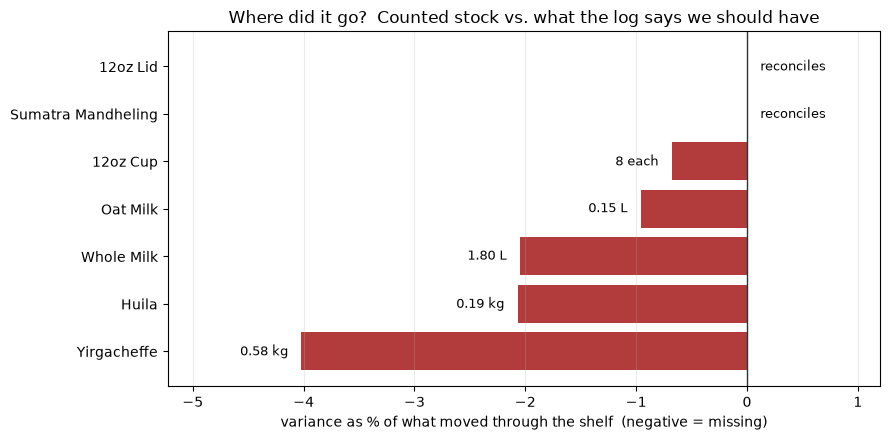

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))

colors = ["#b23b3b" if v < 0 else "#3b7d4f" if v > 0 else "#9a9a9a" for v in reconciliation.variance]
bars = ax.barh(reconciliation.name, reconciliation.variance_pct, color=colors)

for bar, row in zip(bars, reconciliation.itertuples()):
    offset = -0.12 if row.variance_pct < 0 else 0.12
    ax.text(
        row.variance_pct + offset,
        bar.get_y() + bar.get_height() / 2,
        human(abs(row.variance), row.base_unit) if row.variance else "reconciles",
        va="center",
        ha="right" if row.variance_pct < 0 else "left",
        fontsize=9,
    )

ax.axvline(0, color="#333333", linewidth=1)
ax.set_xlabel("variance as % of what moved through the shelf  (negative = missing)")
ax.set_title("Where did it go?  Counted stock vs. what the log says we should have")
# The labels sit outside the ends of the bars, so the margins have to be measured in the
# chart's own units: a fixed nudge that clears them on a 4% spread runs "reconciles" off
# the canvas on a 33% one, which is exactly what real data produces.
span = max(reconciliation.variance_pct.abs().max(), 1.0)
ax.set_xlim(min(reconciliation.variance_pct.min() - 0.3 * span, -1), max(reconciliation.variance_pct.max() + 0.24 * span, 1.2))
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Step 3 — beans bought vs. beans accounted for

The bar chart says *how much*. This one says *where in the week it went missing* — the full path from
the opening count to the closing one for the worst item, with the recorded movements stacked in
between. Everything except the last bar is something a human wrote down. The last bar is the shelf.

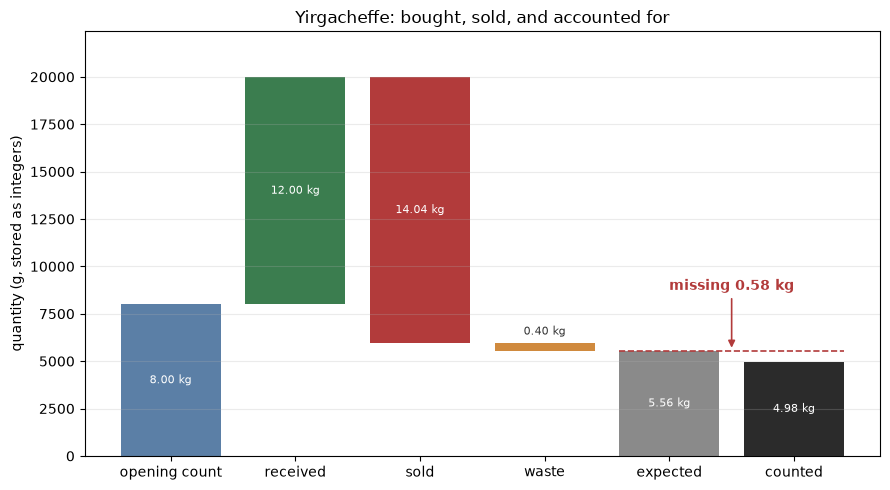

In [8]:
worst = reconciliation.iloc[0]
unit = worst.base_unit

steps = [
    ("opening count", int(worst.opening), "#5b7fa6"),
    ("received", int(worst.received), "#3b7d4f"),
    ("sold", -int(worst.sold), "#b23b3b"),
    ("waste", -int(worst.wasted), "#d08a3e"),
    ("samples", -int(worst.sampled), "#d0b23e"),
]
steps = [step for step in steps if step[1] != 0]

expected, counted = int(worst.expected), int(worst.counted)
ceiling = max(int(worst.opening) + int(worst.received), expected, counted)

fig, ax = plt.subplots(figsize=(9, 5))


def label(x, bottom, height):
    """Label inside the bar, or above it when the bar is too thin to hold text."""
    if height >= 0.06 * ceiling:
        ax.text(x, bottom + height / 2, human(height, unit), ha="center", va="center",
                fontsize=8, color="white")
    else:
        ax.text(x, bottom + height + 0.015 * ceiling, human(height, unit), ha="center",
                va="bottom", fontsize=8, color="#333333")


running = 0
for name, delta, color in steps:
    bottom = running if delta > 0 else running + delta
    ax.bar(name, abs(delta), bottom=bottom, color=color)
    label(name, bottom, abs(delta))
    running += delta

for name, value, color in [("expected", expected, "#8a8a8a"), ("counted", counted, "#2b2b2b")]:
    ax.bar(name, value, color=color)
    label(name, 0, value)

# The gap between the last two bars is the whole finding, so mark it where the eye already is.
ax.hlines(expected, len(steps) - 0.4, len(steps) + 1.4, colors="#b23b3b",
          linestyles="dashed", linewidth=1.2)
ax.annotate(
    f"missing {human(abs(int(worst.variance)), unit)}",
    xy=(len(steps) + 0.5, expected),
    xytext=(len(steps) + 0.5, expected + 0.16 * ceiling),
    ha="center",
    fontsize=10,
    color="#b23b3b",
    fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="#b23b3b", linewidth=1.2),
)

ax.set_ylim(0, ceiling * 1.12)
ax.set_ylabel(f"quantity ({unit}, stored as integers)")
ax.set_title(f"{worst['name']}: bought, sold, and accounted for")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Step 4 — so what is a plausible explanation?

The log tells us how much is missing. It cannot tell us why, because nobody recorded the why — that
is precisely what shrinkage *is*. But the **shape** of the variance narrows the field considerably,
and three explanations are worth taking seriously in a coffee shop.

**1. Over-dosing the shots.** A barista aiming for an 18 g dose and landing on 19 g is out by less
than a coin's weight, invisible in the cup, and completely undetectable at the grinder. Across a
week of service it is the single largest source of unexplained bean loss in most shops. The
arithmetic below converts the bean variance into "extra grams per shot" — if that number lands
somewhere between 0.2 g and 1.5 g, over-dosing explains the gap on its own, and nothing sinister
needs to have happened.

**2. Waste that never got recorded.** A pitcher of steamed milk with 80 ml left in it goes down the
drain, and nobody stops mid-rush to record 80 ml of waste. This shows up in the milks, not the beans,
and it scales with drink volume rather than with anything a thief would care about.

**3. Spoilage and staling.** Real, but this shop already *records* it — there is a `waste` event in
the log for a stale batch. Recorded waste is not shrinkage; it is subtracted in the `expected`
column above. Spoilage only contributes to the gap when it goes unrecorded, which usually means it
happened somewhere nobody was looking: a bag left open, a delivery short-shipped and signed for
without weighing.

Against all of that, the thing to watch for is an item whose variance **does not** fit these shapes —
a packaging item walking off, or a single expensive origin drifting while its shelf-mates reconcile.

In [9]:
NOMINAL_DOSE_G = 18  # the shop's target espresso dose

beans = select_category(reconciliation, BEANS).copy()
beans["shots_sold"] = (beans.sold / NOMINAL_DOSE_G).round().astype(int)
beans["extra_g_per_shot"] = (beans.variance.abs() / beans.shots_sold).round(2)
beans["reads_as"] = beans.apply(
    lambda r: "reconciles -- nothing to explain"
    if r.variance == 0
    else f"every shot ran ~{NOMINAL_DOSE_G + r.extra_g_per_shot:.1f} g instead of {NOMINAL_DOSE_G} g",
    axis=1,
)

print(f"Assuming a nominal {NOMINAL_DOSE_G} g dose, the missing beans work out as:\n")
for r in beans.itertuples():
    print(f"  {r.name:<22} {r.shots_sold:>5} shots   {r.reads_as}")

beans[["name", "sold", "shots_sold", "variance", "extra_g_per_shot"]]

Assuming a nominal 18 g dose, the missing beans work out as:

  Yirgacheffe              780 shots   every shot ran ~18.7 g instead of 18 g
  Huila                    511 shots   every shot ran ~18.4 g instead of 18 g
  Sumatra Mandheling       194 shots   reconciles -- nothing to explain


,name,sold,shots_sold,variance,extra_g_per_shot
0,Yirgacheffe,14040,780,-580,0.74
1,Huila,9200,511,-190,0.37
5,Sumatra Mandheling,3500,194,0,0.00


In [10]:
milk = select_category(reconciliation, MILK)
packaging = select_category(reconciliation, PACKAGING)

print("Milk -- unrecorded pitcher waste scales with volume poured:\n")
for r in milk.itertuples():
    poured = human(int(r.throughput), r.base_unit)
    if r.variance == 0:
        print(f"  {r.name:<22} reconciles over the {poured} poured")
        continue
    print(f"  {r.name:<22} short {human(abs(int(r.variance)), r.base_unit):>10}"
          f"   = {abs(r.variance_pct):.1f}% of the {poured} poured")

print("\nPackaging -- these should reconcile almost exactly, so any gap is worth a question:\n")
for r in packaging.itertuples():
    verdict = "reconciles" if r.variance == 0 else f"short {abs(int(r.variance))} -- dropped, double-cupped, or taken"
    print(f"  {r.name:<22} {verdict}")

Milk -- unrecorded pitcher waste scales with volume poured:

  Whole Milk             short     1.80 L   = 2.0% of the 88.00 L poured
  Oat Milk               short     0.15 L   = 1.0% of the 15.60 L poured

Packaging -- these should reconcile almost exactly, so any gap is worth a question:

  12oz Cup               short 8 -- dropped, double-cupped, or taken
  12oz Lid               reconciles


## What would make this conclusive

Everything above is inference. The reason it has to be inference is that the shop records a *sale*
as a bean depletion in grams, typed in by a human at close of day — so "how much coffee should this
week's drinks have used" is itself an estimate, and the shrinkage number inherits that error.

The fix is not a better notebook. It is a better event: a recipe (a bill of materials) so that
selling one latte deplete 18 g of beans, 200 ml of milk, one cup and one lid, deterministically,
from the single fact that a latte was sold. Then `expected` stops being an estimate, and the residue
is real shrinkage rather than the sum of shrinkage and data-entry noise.

That change is written up as `openspec/changes/add-recipe-bom-depletion/` — with the design note
that once recipes exist, this notebook's variance splits cleanly into *explained by recipe* and
*unexplained remainder*, which is the number a manager can actually act on.

Two caveats to keep attached to any number from this notebook:

- **A count is evidence, not truth.** A miscount produces exactly the same signal as theft. This is
  why `openspec/changes/add-auth-and-roles/` restricts who may record a `StockCounted`: the event
  that measures shrinkage is also the event that can erase it.
- **One week is one data point.** A single count window cannot separate a persistent 4% drift from
  one bad Saturday. Run this across several windows before drawing a conclusion about a person.